# Business Case Yulu - Hypothesis Testing

# About Yulu

Yulu is India’s leading micro-mobility service provider, which offers unique vehicles for the daily commute. Starting off as a mission to eliminate traffic congestion in India, Yulu provides the safest commute solution through a user-friendly mobile app to enable shared, solo and sustainable commuting.

Yulu zones are located at all the appropriate locations (including metro stations, bus stands, office spaces, residential areas, corporate offices, etc) to make those first and last miles smooth, affordable, and convenient!

Yulu has recently suffered considerable dips in its revenues. They have contracted a consulting company to understand the factors on which the demand for these shared electric cycles depends. Specifically, they want to understand the factors affecting the demand for these shared electric cycles in the Indian market.

# Column Profiling:
* datetime: datetime
* season: season (1: spring, 2: summer, 3: fall, 4: winter)
* holiday: whether day is a holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
* workingday: if day is neither weekend nor holiday is 1, otherwise is 0.
* weather:
    1. Clear, Few clouds, partly cloudy, partly cloudy
    2. Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    3. Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    4. Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
* temp: temperature in Celsius
* atemp: feeling temperature in Celsius
* humidity: humidity
* windspeed: wind speed
* casual: count of casual users
* registered: count of registered users
* count: count of total rental bikes including both casual and registered

In [1]:
# Import the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing the data

df = pd.read_csv(r"D:\Scaler\06 Data Analytics and Visualisation - Fundamentals\Business Case Study\02 Business Case Yulu - Hypothesis Testing\bike_sharing.txt")

In [3]:
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


# 1. Define Problem Statement and perform Exploratory Data Analysis

### 1.1 Definition of problem (as per given problem statement with additional views)

Yulu, a micro-mobility provider in India, is experiencing a decrease in revenue and wants to understand the factors that affect the demand for its shared electric cycles. Specifically, we need to analyze data on various factors (e.g., season, weather, temperature, humidity, holidays, working days) to identify patterns that drive demand. This understanding will support strategic decision-making to optimize the service and improve revenue.

### 1.2 Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required) , missing value detection, statistical summary

In [4]:
df.shape

(10886, 12)

In [5]:
df.dtypes

datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [7]:
df.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [8]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [9]:
categorical_columns = ['season', 'holiday', 'workingday', 'weather']
df[categorical_columns] = df[categorical_columns].astype('object')

In [10]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [11]:
df.dtypes

datetime      datetime64[ns]
season                object
holiday               object
workingday            object
weather               object
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dtype: object

In [12]:
df.describe()

,datetime,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454


### 1.3 Univariate Analysis (distribution plots of all the continuous variable(s) barplots/countplots of all the categorical variables)

In [13]:
continuous_columns = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
categorical_columns = ['season', 'holiday', 'workingday', 'weather']

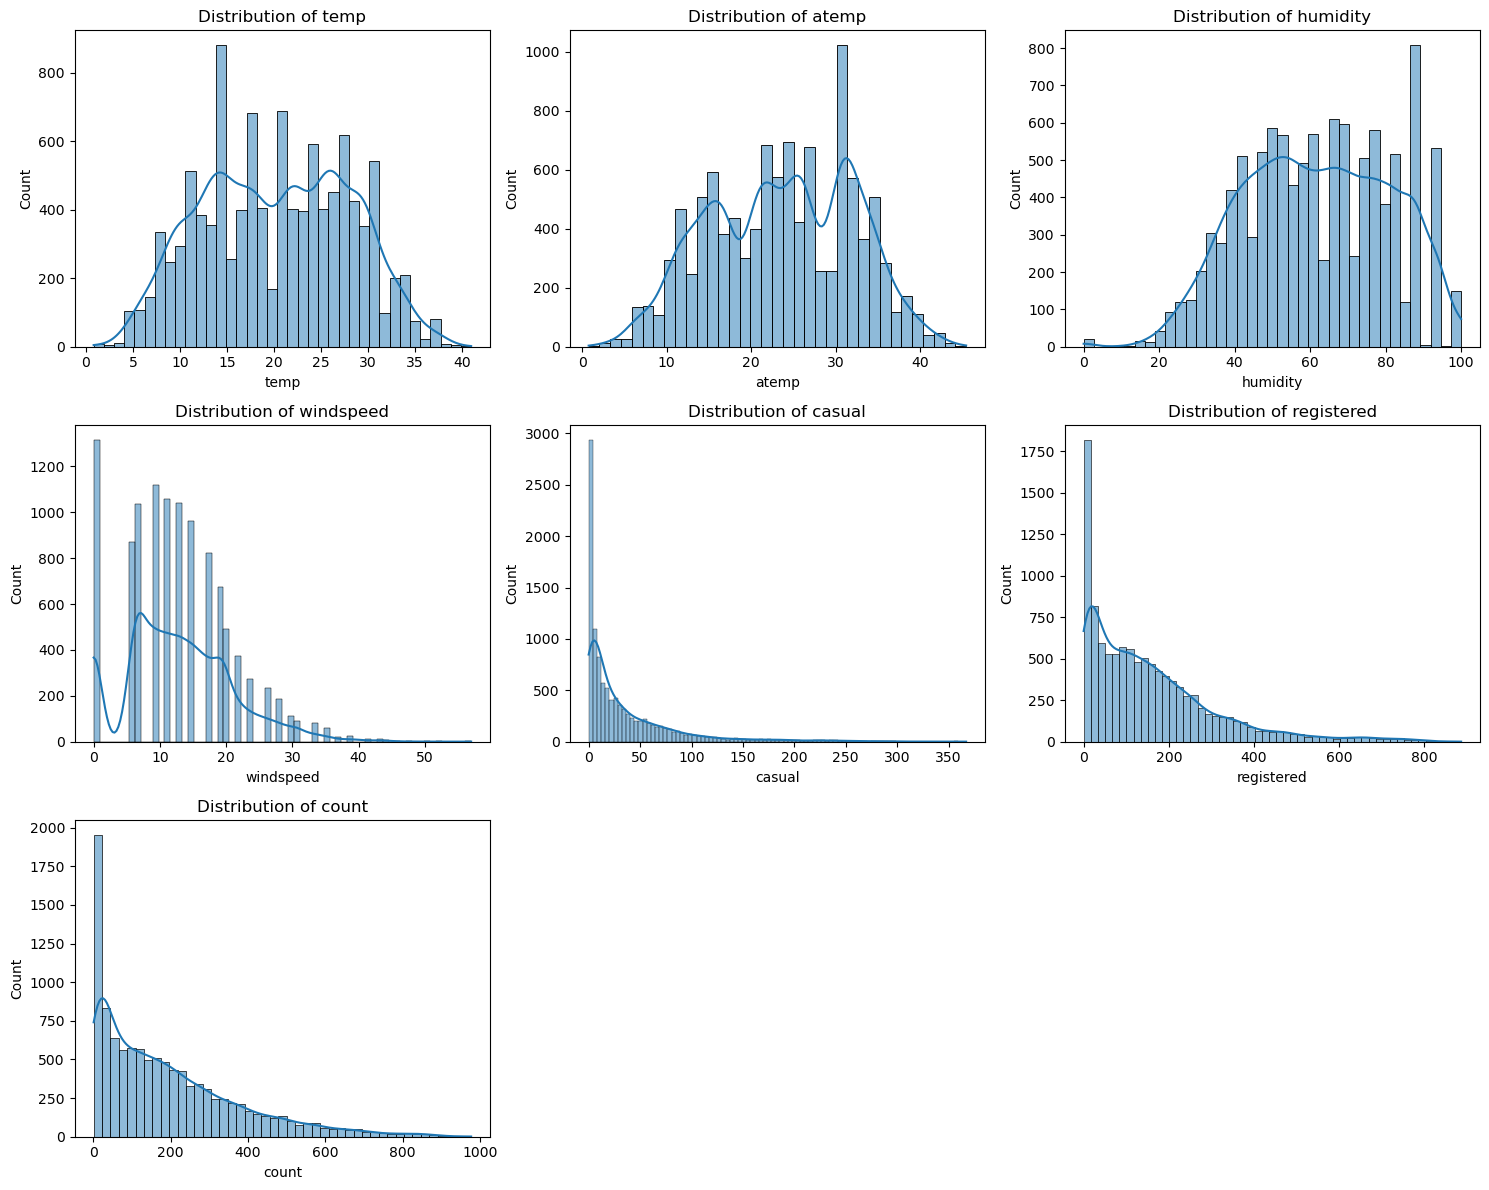

In [14]:
# Distribution Plots for Continuous Variables

plt.figure(figsize=(15, 12))
for i, col in enumerate(continuous_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

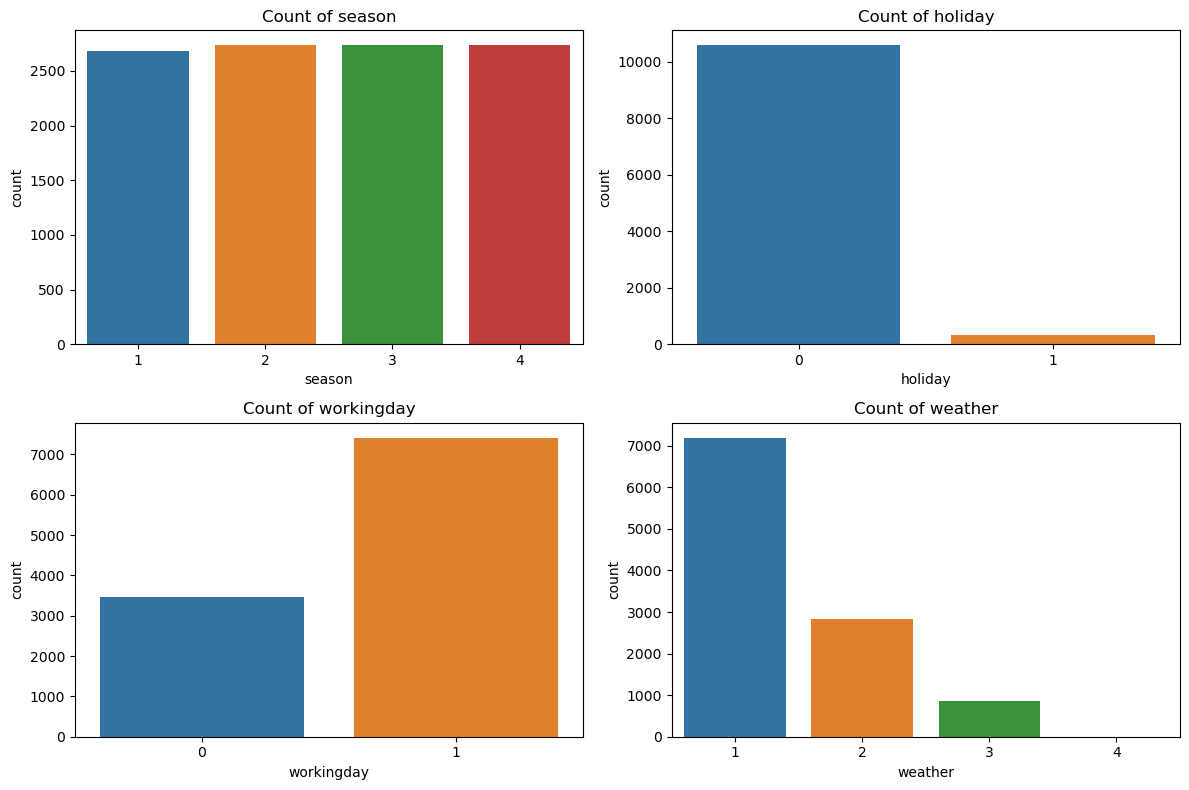

In [15]:
# Bar Plots for Categorical Variables

plt.figure(figsize=(12, 8))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, data=df)
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

### 1.4 Bivariate Analysis (Relationships between important variables such as workday and count, season and count, weather and count.

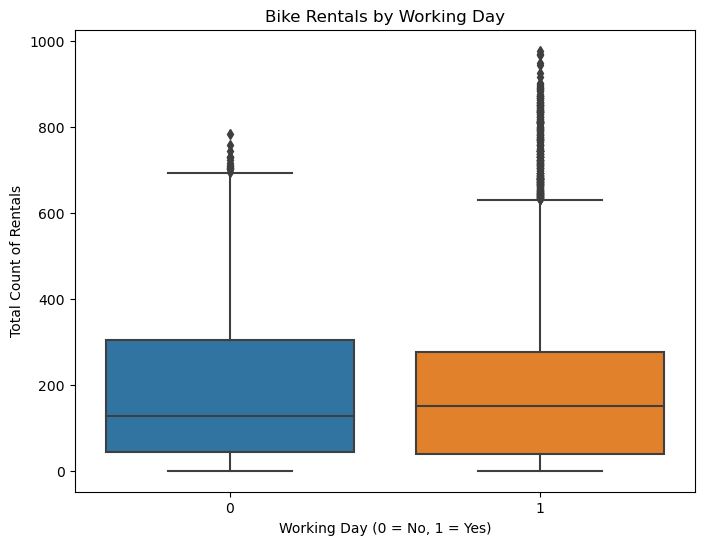

In [16]:
# Relationship between workingday and count

plt.figure(figsize=(8, 6))
sns.boxplot(x='workingday', y='count', data=df)
plt.title('Bike Rentals by Working Day')
plt.xlabel('Working Day (0 = No, 1 = Yes)')
plt.ylabel('Total Count of Rentals')
plt.show()

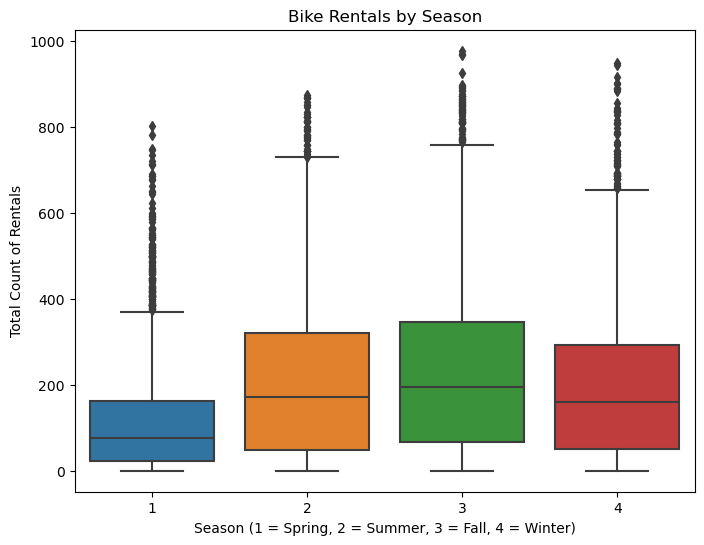

In [17]:
# relationship between season and count

plt.figure(figsize=(8, 6))
sns.boxplot(x='season', y='count', data=df)
plt.title('Bike Rentals by Season')
plt.xlabel('Season (1 = Spring, 2 = Summer, 3 = Fall, 4 = Winter)')
plt.ylabel('Total Count of Rentals')
plt.show()

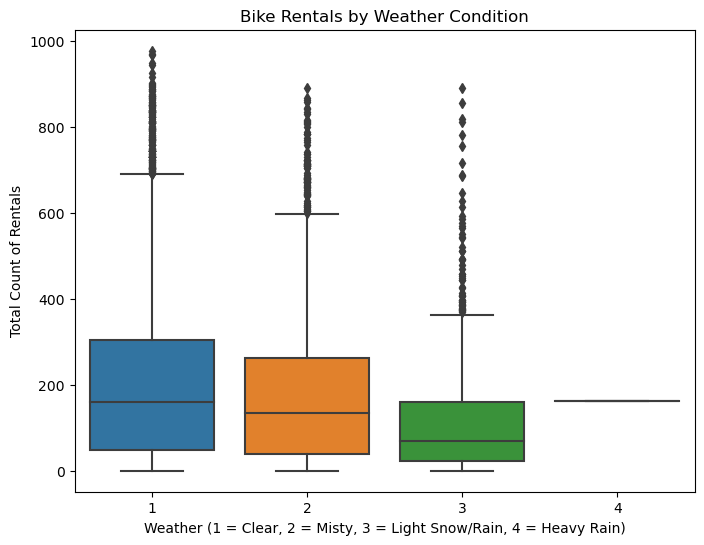

In [18]:
# relationship between weather and count

plt.figure(figsize=(8, 6))
sns.boxplot(x='weather', y='count', data=df)
plt.title('Bike Rentals by Weather Condition')
plt.xlabel('Weather (1 = Clear, 2 = Misty, 3 = Light Snow/Rain, 4 = Heavy Rain)')
plt.ylabel('Total Count of Rentals')
plt.show()

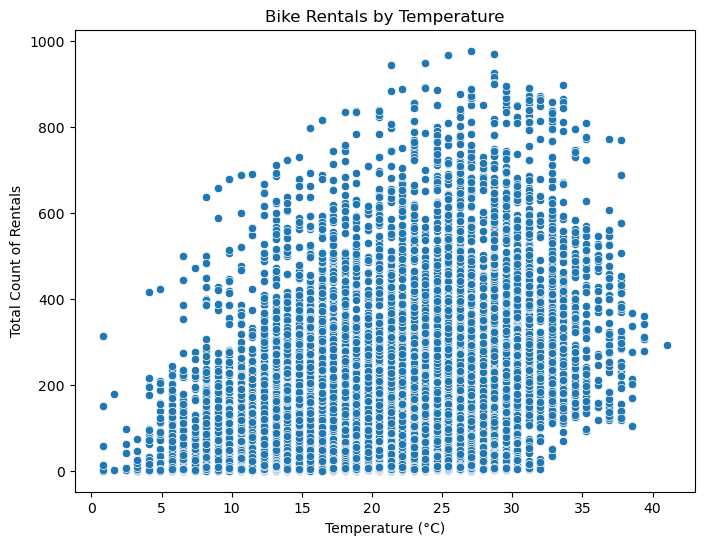

In [19]:
# scatter plot for temp vs count

plt.figure(figsize=(8, 6))
sns.scatterplot(x='temp', y='count', data=df)
plt.title('Bike Rentals by Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Total Count of Rentals')
plt.show()

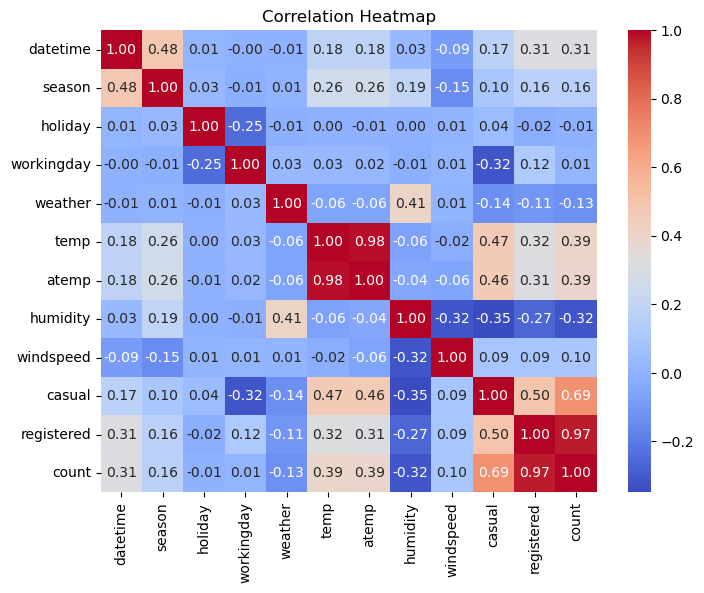

In [20]:
# heatmap for correlation

correlation_matrix = df.corr()

# Plot heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

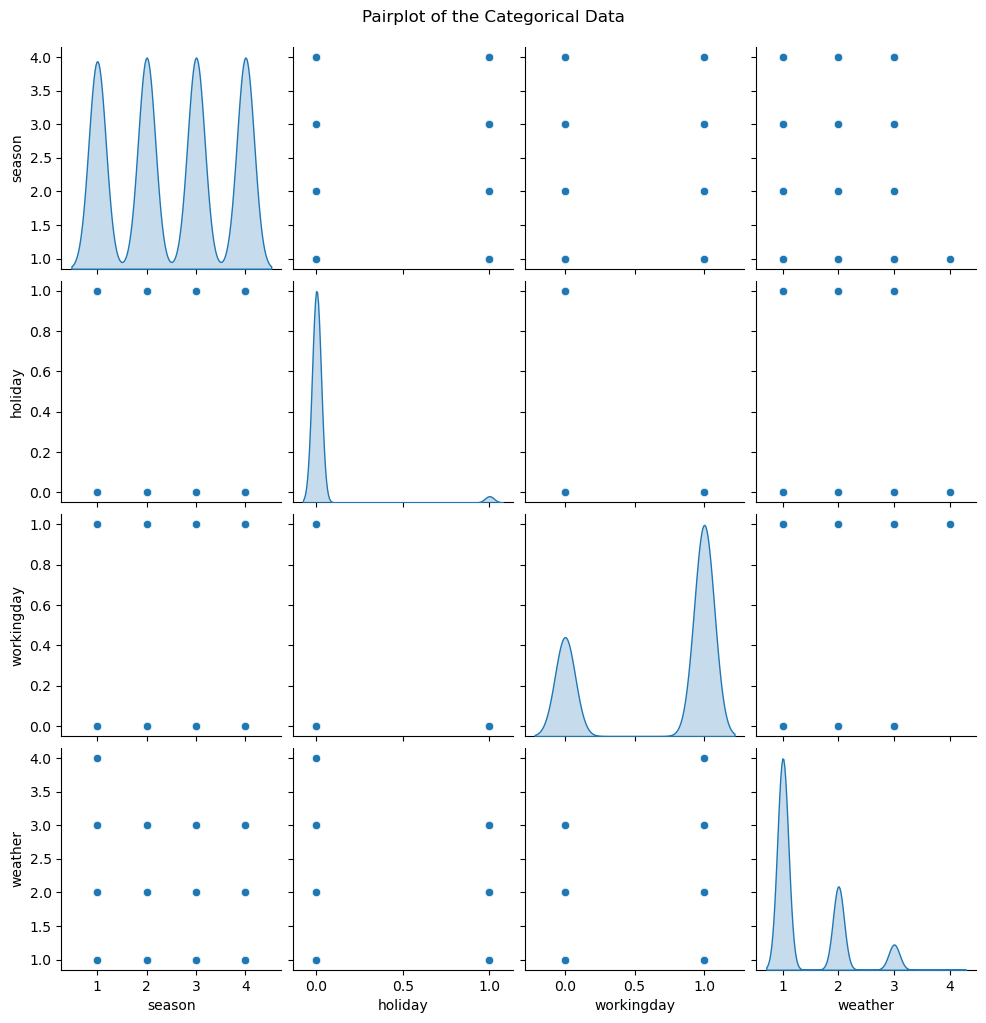

In [21]:
# pairplot for categorical columns

sns.pairplot(df[categorical_columns], diag_kind='kde')
plt.suptitle("Pairplot of the Categorical Data", y=1.02)
plt.show()

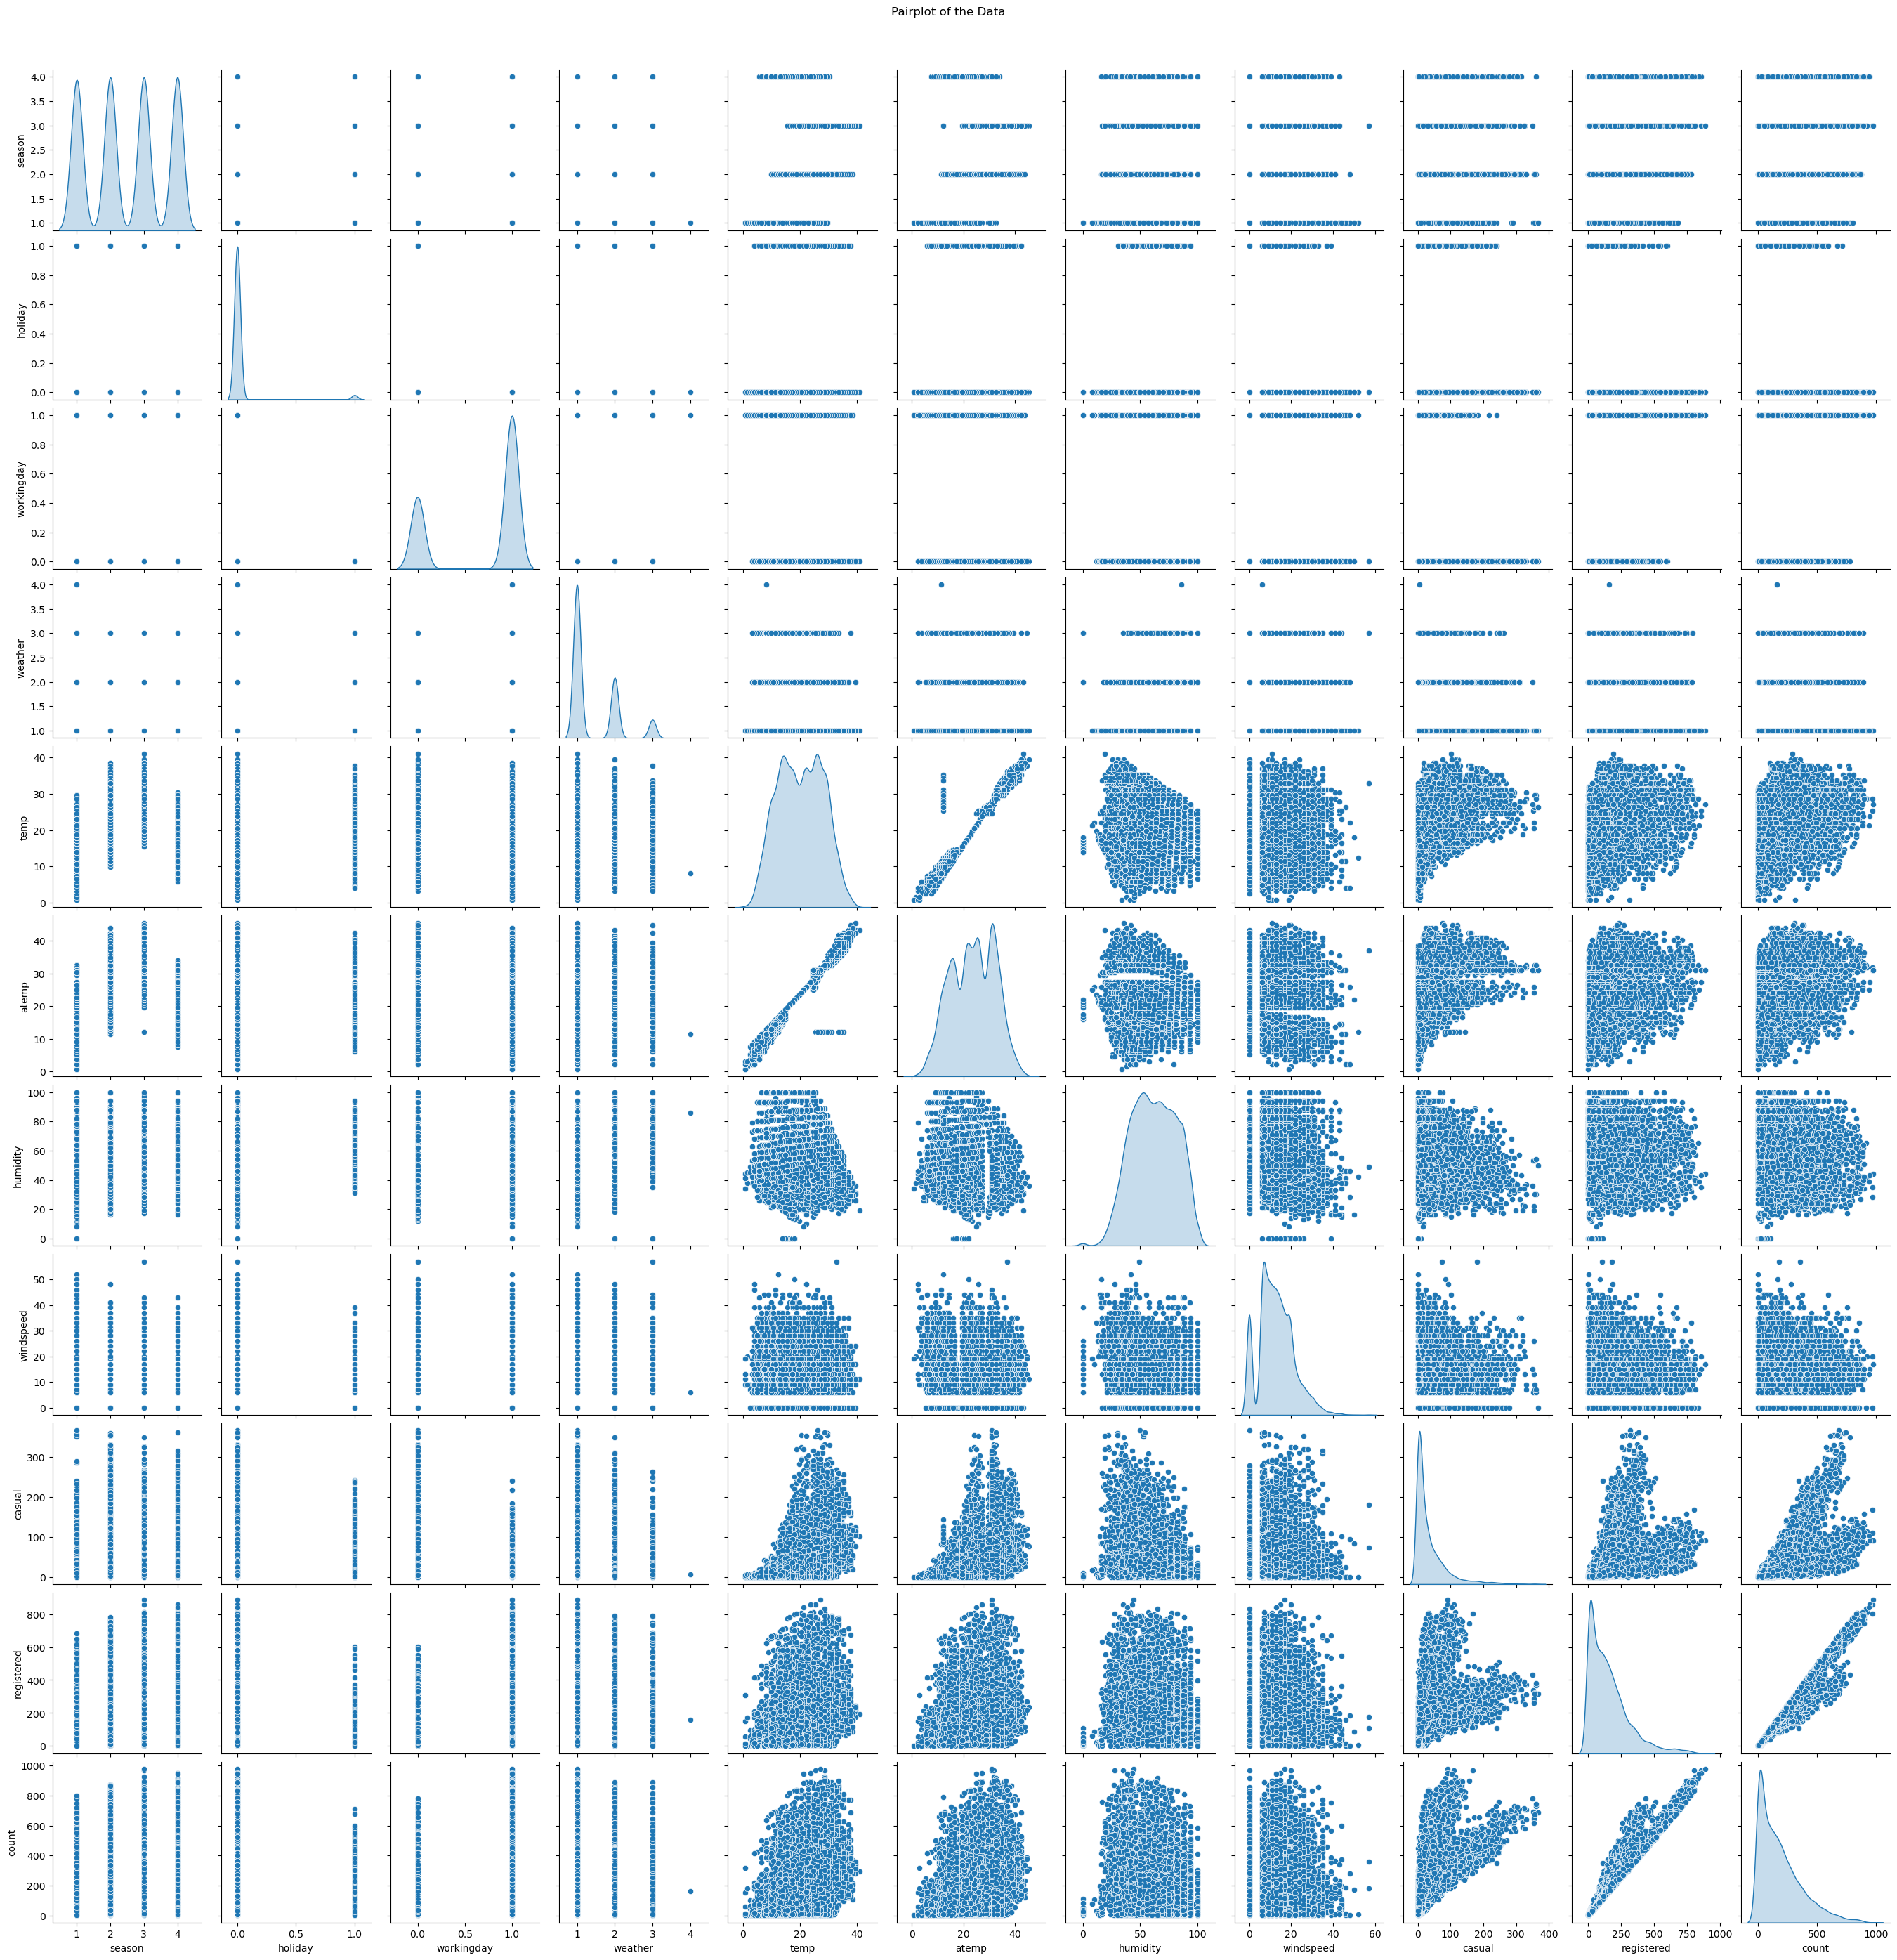

In [22]:
# pairplot for entire data

sns.pairplot(df, diag_kind='kde')
plt.suptitle("Pairplot of the Data", y=1.02)
plt.show()

### 1.5 Illustrate the insights based on EDA

#### 1.5.1 Comments on range of attributes, outliers of various attributes

1. Continuous Variables:

    * Temperature (temp and atemp): Range from around 0.8°C to 45°C, covering various seasonal temperatures.
    * Humidity: Range from 0% to 100%; higher humidity is common, typical of Indian climates.
    * Wind Speed: Ranges from 0 to 56.99; moderate values dominate, but high speeds may deter riders.
    * User Counts (casual, registered, count):
        * Casual rentals range from 0 to 367, with more variability, likely due to weekend or holiday activity.
        * Registered rentals range from 0 to 886, indicating a stable commuting base.
        * Total rentals range from 1 to 977, with high counts during peak times or favorable conditions.

2. Categorical Variables:

    * Season: Data spans all seasons (1: Spring to 4: Winter), showing seasonal rental trends.
    * Holiday: Binary (0 = non-holiday, 1 = holiday); majority are non-holidays.
    * Working Day: Binary (0 or 1), distinguishing commuting and recreational usage.
    * Weather: From 1 (Clear) to 4 (Heavy Rain/Snow), highlighting weather sensitivity in rentals.

3. Outliers
    * Temperature (temp and atemp): No significant outliers; all values fall within expected ranges.
    * Humidity: Outliers at 0% and 100%, potentially indicating rare weather or data anomalies.
    * Wind Speed: Some high outliers near maximum values (~57); could impact rentals due to discomfort.
    * User Counts (casual and registered):
        * Casual user count outliers indicate high demand on weekends or events.
        * Registered user count shows consistent high values, likely due to daily commuters.
    * Total Rentals (count): High outliers near maximum range (977 rentals), likely during peak conditions (e.g., weekends, clear weather).


#### 1.5.2 Comments on the distribution of the variables and relationship between them

1. Distribution of Variables
    * Temperature (temp and atemp):
        * From the distribution plot, both temp and atemp show a roughly normal distribution with peaks around 20°C, indicating moderate to warm temperatures dominate the dataset.
        * Warmer temperatures generally correspond with increased rentals, as shown by the trend in the rental distribution by temperature.

    * Humidity:
        * The right-skewed distribution of humidity shows more data points in the higher range (50-100%). This distribution might indicate the predominance of humid conditions.
        * High humidity may discourage rentals, especially above certain thresholds, as seen in the relationship plot with rental counts.

    * Wind Speed:
        * The left-skewed distribution plot of wind speed shows that lower wind speeds are more common, and few days experience high wind speeds (above 30).
        * There’s a slight negative correlation between wind speed and rentals, as high wind speeds likely deter users.

    * User Types (casual and registered):
        * Casual users have a left-skewed distribution, with lower rentals more common, suggesting that casual users generally rent less frequently or during specific periods like weekends.
        * Registered users show a more left-skewed distribution.

    * Total Rentals (count):
        * The total rental count is left-skewed, as moderate rental days are most common with occasional high-rental days. High rental counts often correspond to favorable weather and working days.

    * Categorical Variables (Season, Holiday, Working Day, Weather):
        * Season: Each season shows a different distribution, with warmer seasons (summer, fall) showing higher rental counts. Winter sees a decrease, aligning with expectations as colder weather may deter outdoor activity.
        * Holiday: Most rentals occur on non-holidays, but casual rentals increase on holidays, seen in the comparison of holiday vs. non-holiday counts.
        * Working Day: Higher rentals on working days reflect commuter demand. This pattern, visible in the working day vs. rental plot, shows a consistent trend of registered users renting on working days.
        * Weather: Rentals are highest under clear weather (weather = 1) and decrease under worse conditions (e.g., rain or snow), confirming the weather sensitivity of demand.

2. Relationships Between Variables

    * Temperature and Total Rentals:
        * As seen in the scatter and line plots, rentals increase with temperature, indicating a positive relationship. However, demand plateaus or decreases slightly at very high temperatures, suggesting an upper comfort limit for users.

    * Humidity and Total Rentals:
        * Higher humidity levels show a negative correlation with rentals. As humidity increases, rental demand slightly decreases, likely due to discomfort in overly humid conditions.
    
    * Wind Speed and Total Rentals:
        * High wind speeds tend to correlate with reduced rentals, suggesting that users prefer lower wind conditions for biking. This negative correlation is visible in the scatter plot of wind speed vs. rentals.

    * User Types (Casual vs. Registered) and Working Day:
        * Registered users show high rental counts on working days, indicating a strong commuter base.
        * Casual users show increased rentals on weekends or holidays, suggesting that their rentals are more recreational. This distinction is evident in the bar plots comparing rental types by day.

    * Season and Rentals:
        * Warmer seasons (summer and fall) show higher rental counts, while winter sees a dip, confirming that bike demand is seasonal. Seasonal rental variations are clearly visible in the seasonal bar plot.

    * Weather and Rentals:
        * Clear weather days (weather = 1) show the highest rentals, while bad weather (heavy rain or snow) corresponds with reduced rentals. This relationship, visible in the weather vs. rentals plot, highlights that demand drops in adverse weather conditions.

#### 1.5.3 Comments for each univariate and bivariate plots

1. Univariate Plot Comments
    * Temperature (temp):
        * The distribution plot of temperature shows a normal distribution, with a peak around 20°C. This indicates that most rentals occur at moderate temperatures, with fewer days in extreme cold or hot ranges.
        * Warmer temperatures appear to encourage rentals, which aligns with expectations that users prefer outdoor activities in moderate to warm weather.

    * Feels-like Temperature (atemp):
        * Similar to temp, atemp follows a normal distribution, with most values around 20-25°C.
        * The close relationship between temp and atemp suggests that perceived and actual temperatures have a similar influence on user comfort and rental demand.

    * Humidity:
        * The right-skewed distribution indicates that many days have high humidity (50-100%).
        * Higher humidity might reduce rental comfort, which is a potential deterrent for both casual and registered users.

    * Wind Speed:
        * The left-skewed distribution shows most days with moderate to low wind speeds, and very few days have high wind speeds.
        * Calm conditions are preferable, as users may find high wind speeds uncomfortable or unsafe for biking.

    * Casual and Registered Users:
        * Casual users have a left-skewed distribution, with most rentals at lower counts. Peaks on weekends and holidays suggest casual users tend to rent on specific non-working days.
        * Registered users show a more normal distribution with a peak around moderate counts, indicating consistent usage patterns likely related to weekday commuting.

    * Total Rentals (count):
        * The left-skewed distribution suggests most days have moderate rentals, with occasional high-demand days.
        * High demand days could correspond to favorable conditions like good weather and working days, with fewer rentals during off-peak periods.

    * Season:
        * The bar plot shows relatively even distribution across seasons, with warmer seasons (summer and fall) seeing slightly higher rentals.
        * This suggests a seasonal influence on demand, with more rentals in warmer weather and fewer in colder seasons.

    * Holiday:
        * The plot shows that most rentals occur on non-holiday days, as expected since working days make up the bulk of the data.
        * Casual rentals increase on holidays, highlighting a recreational usage pattern among non-registered users on these days.

    * Working Day:
        * Higher rentals on working days indicate a strong commuter demand from registered users.
        * Non-working days see fewer rentals overall, though casual users tend to rent more on these days.

    * Weather:
        * Clear weather conditions (weather = 1) show the highest rental counts, while adverse weather (e.g., heavy rain, snow) corresponds with reduced rentals.
        * This shows that favorable weather conditions drive higher demand, with drops in poor weather.

2. Bivariate Plot Comments

    * Temperature vs. Total Rentals (temp vs. count):
        * A positive relationship is observed, where rentals increase with temperature up to a point, suggesting that users are more likely to rent on warmer days.
        * However, rentals may drop at very high temperatures, indicating a potential comfort threshold beyond which users might avoid outdoor activities.

    * Humidity vs. Total Rentals (humidity vs. count):
        * Higher humidity levels show a negative correlation with rentals, as increased humidity likely makes biking less comfortable.
        * Moderate humidity appears to be more favorable, while extreme levels, either high or low, see fewer rentals.

    * Wind Speed vs. Total Rentals (windspeed vs. count):
        * Rentals tend to decrease with high wind speeds, showing a negative relationship between wind speed and demand.
        * This suggests that users prefer calm conditions, as strong winds may make biking challenging or uncomfortable.
    
    * Working Day vs. Total Rentals (workingday vs. count):
        * Rental counts are higher on working days, particularly from registered users, who rely on bikes for commuting.
        * Casual rentals increase on non-working days, highlighting a difference in usage patterns between user types.

    * Holiday vs. Total Rentals (holiday vs. count):
        * Non-holiday days show higher rentals from registered users, while casual user counts increase on holidays.
        * This distinction suggests that casual users rent bikes for recreational purposes, while registered users are more consistent, likely commuting on working days.

    * Season vs. Total Rentals (season vs. count):
        * Warmer seasons (summer, fall) see higher rentals compared to colder seasons, suggesting a seasonal trend in demand.
        * This indicates that users are more likely to rent in comfortable, warmer weather and less so in winter.

    * Weather vs. Total Rentals (weather vs. count):
        * Clear weather sees the highest rentals, with demand decreasing as weather conditions worsen (e.g., rain or snow).
        * This relationship suggests that users are weather-sensitive, preferring to ride in good conditions and avoiding rentals during inclement weather.

    * Casual vs. Registered Users:
        * Casual users tend to rent on weekends or holidays, whereas registered users show higher demand on working days, confirming distinct behavior patterns.
        * This difference can be leveraged for targeted marketing, with weekends appealing to casual users and weekday promotions focused on registered users.


# 2. Hypothesis Testing 

### 2.1 2- Sample T-Test to check if Working Day has an effect on the number of electric cycles rented

In [23]:
# import the t-test library

from scipy.stats import ttest_ind

# split data into working day and non-working day groups

workingday_rentals = df[df['workingday'] == 1]['count']
non_workingday_rentals = df[df['workingday'] == 0]['count']

In [24]:
# perform 2-sample T-Test

t_stat, p_value = ttest_ind(workingday_rentals, non_workingday_rentals, equal_var=False)

# Output results

print("T-Statistic:", t_stat)
print("P-Value:", p_value)


print('---------------------------------------------------------------------------------------------------------')
if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in rentals on working vs. non-working days.")
else:
    print("Fail to reject the null hypothesis: No significant difference in rentals on working vs. non-working days.")

T-Statistic: 1.2362580418223226
P-Value: 0.21640312280695098
---------------------------------------------------------------------------------------------------------
Fail to reject the null hypothesis: No significant difference in rentals on working vs. non-working days.


### 2.2 ANNOVA to check if No. of cycles rented is similar or different in different 1. weather 2. season

In [25]:
#import ANOVA library

from scipy.stats import f_oneway

# ANOVA for 'weather'

group_weather = [df[df['weather'] == i]['count'] for i in df['weather'].unique()]
f_stat_weather, p_value_weather = f_oneway(*group_weather)


# Results for 'weather'

print("ANOVA for Weather:")
print("F-Statistic:", f_stat_weather)
print("P-Value:", p_value_weather)

print('------------------------------------------------------------------------------------------------')
if p_value_weather < 0.05:
    print("Reject the null hypothesis: The mean number of cycles rented differs across weather conditions.")
else:
    print("Fail to reject the null hypothesis: The mean number of cycles rented does not differ across weather conditions.")

ANOVA for Weather:
F-Statistic: 65.53024112793271
P-Value: 5.482069475935669e-42
------------------------------------------------------------------------------------------------
Reject the null hypothesis: The mean number of cycles rented differs across weather conditions.


In [26]:
# ANOVA for 'season'

group_season = [df[df['season'] == i]['count'] for i in df['season'].unique()]
f_stat_season, p_value_season = f_oneway(*group_season)

# Results for 'season'

print("\nANOVA for Season:")
print("F-Statistic:", f_stat_season)
print("P-Value:", p_value_season)

print('------------------------------------------------------------------------------------')
if p_value_season < 0.05:
    print("Reject the null hypothesis: The mean number of cycles rented differs across seasons.")
else:
    print("Fail to reject the null hypothesis: The mean number of cycles rented does not differ across seasons.")



ANOVA for Season:
F-Statistic: 236.94671081032106
P-Value: 6.164843386499654e-149
------------------------------------------------------------------------------------
Reject the null hypothesis: The mean number of cycles rented differs across seasons.


### 2.3 Chi-square test to check if Weather is dependent on the season

In [27]:
#import Chi-Square library

from scipy.stats import chi2_contingency

# Create a table for 'weather' and 'season'

crosstab_table = pd.crosstab(df['weather'], df['season'])

In [28]:
# Perform Chi-square test

chi2_stat, p_value, dof, expected = chi2_contingency(crosstab_table)

# Output the results

print("Chi-Square Statistic:", chi2_stat)
print("P-Value:", p_value)
print("Degrees of Freedom:", dof)
print("Expected Frequencies Table:\n", expected)

print('---------------------------------------------------------------')
if p_value < 0.05:
    print("Reject the null hypothesis: Weather is dependent on the season.")
else:
    print("Fail to reject the null hypothesis: Weather is independent of the season.")

Chi-Square Statistic: 49.15865559689363
P-Value: 1.5499250736864862e-07
Degrees of Freedom: 9
Expected Frequencies Table:
 [[1.77454639e+03 1.80559765e+03 1.80559765e+03 1.80625831e+03]
 [6.99258130e+02 7.11493845e+02 7.11493845e+02 7.11754180e+02]
 [2.11948742e+02 2.15657450e+02 2.15657450e+02 2.15736359e+02]
 [2.46738931e-01 2.51056403e-01 2.51056403e-01 2.51148264e-01]]
---------------------------------------------------------------
Reject the null hypothesis: Weather is dependent on the season.
